## ```Employee Attrition Prediction```

📌 Kaggle Dataset

IBM HR Analytics Employee Attrition & Performance

## ```Phase 1 : Problem Understanding```

## ` Step 1.1 : Business Problem`

### Employee Attrition Prediction

## Business Problem

Employee attrition refers to the situation where employees leave an organization voluntarily or involuntarily.

High attrition can lead to increased recruitment costs, productivity loss, knowledge gaps, and reduced organizational performance.

The objective of this project is to build a machine learning model that predicts whether an employee is likely to leave the company based on demographic, job-related, and performance-related attributes.

Such predictions help HR departments identify at-risk employees and take proactive retention measures.

## ``Step 1.2 : Machine Learning Problem``

## Machine Learning Problem

This is a Binary Classification problem.

Target Variable:

Attrition

Classes:

- Yes
- No

## ```Step 1.3 : Success Metric```

## Success Metric

The model will be evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

Since identifying employees who are likely to leave is important, Recall and F1-Score will receive special attention during model evaluation.

# ``Phase 2 : Data Understanding``

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [50]:
## import csv data

import pandas as pd

df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [51]:
from IPython.display import display
import pandas as pd

print('='*60)
print('📊 EXPLORATORY DATA ANALYSIS (EDA) SUMMARY')
print('='*60)

print('\n📌 Dataset Shape')
print(df.shape)

print('\n📌 First 5 Rows')
display(df.head())

print('\n📌 Last 5 Rows')
display(df.tail())

print('\n📌 Random Sample')
display(df.sample(5))

print('\n📌 Column Names')
display(pd.DataFrame(df.columns, columns=['Columns']))

print('\n📌 Data Types')
display(df.dtypes.to_frame('Data Type'))

print('\n📌 Dataset Information')
df.info()

print('\n📌 Missing Values')
display(df.isnull().sum().to_frame('Missing Values'))

print('\n📌 Duplicate Rows')
print(df.duplicated().sum())

print('\n📌 Numerical Summary')
display(df.describe().T)

print('\n📌 Categorical Summary')
display(df.describe(include='object').T)

print('\n📌 Correlation Matrix')
display(df.corr(numeric_only=True))

print('\n✅ EDA Completed Successfully!')

📊 EXPLORATORY DATA ANALYSIS (EDA) SUMMARY

📌 Dataset Shape
(1470, 35)

📌 First 5 Rows


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2



📌 Last 5 Rows


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2



📌 Random Sample


...


📌 Categorical Summary


,count,unique,top,freq
Attrition,1470,2,No,1233
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
Over18,1470,1,Y,1470
OverTime,1470,2,No,1054



📌 Correlation Matrix


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.010661,-0.001686,0.208034,NaN,-0.010145,0.010146,0.024287,0.029820,0.509604,...,0.053535,NaN,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089
DailyRate,0.010661,1.000000,-0.004985,-0.016806,NaN,-0.050990,0.018355,0.023381,0.046135,0.002966,...,0.007846,NaN,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363
DistanceFromHome,-0.001686,-0.004985,1.000000,0.021042,NaN,0.032916,-0.016075,0.031131,0.008783,0.005303,...,0.006557,NaN,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406
Education,0.208034,-0.016806,0.021042,1.000000,NaN,0.042070,-0.027128,0.016775,0.042438,0.101589,...,-0.009118,NaN,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065
EmployeeCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeNumber,-0.010145,-0.050990,0.032916,0.042070,NaN,1.000000,0.017621,0.035179,-0.006888,-0.018519,...,-0.069861,NaN,0.062227,-0.014365,0.023603,0.010309,-0.011240,-0.008416,-0.009019,-0.009197
EnvironmentSatisfaction,0.010146,0.018355,-0.016075,-0.027128,NaN,0.017621,1.000000,-0.049857,-0.008278,0.001212,...,0.007665,NaN,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999
HourlyRate,0.024287,0.023381,0.031131,0.016775,NaN,0.035179,-0.049857,1.000000,0.042861,-0.027853,...,0.001330,NaN,0.050263,-0.002334,-0.008548,-0.004607,-0.019582,-0.024106,-0.026716,-0.020123
JobInvolvement,0.029820,0.046135,0.008783,0.042438,NaN,-0.006888,-0.008278,0.042861,1.000000,-0.012630,...,0.034297,NaN,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976
JobLevel,0.509604,0.002966,0.005303,0.101589,NaN,-0.018519,0.001212,-0.027853,-0.012630,1.000000,...,0.021642,NaN,0.013984,0.782208,-0.018191,0.037818,0.534739,0.389447,0.353885,0.375281



✅ EDA Completed Successfully!


# `Phase 3 : Exploratory Data Analysis (EDA)`

## ```Step 3.1 : Target Variable Distribution```

Employee Attrition (Target Variable) ka distribution dekhna taaki pata chale dataset balanced hai ya imbalanced.

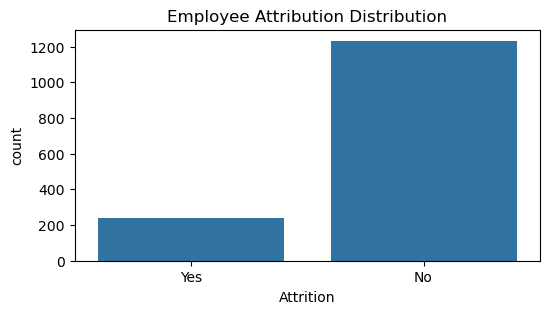

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


In [52]:
plt.figure(figsize=(6,3))
sns.countplot(
    x = "Attrition",
    data=df,
)
plt.title("Employee Attribution Distribution")
plt.show()

print(df["Attrition"].value_counts())
print()
print(df["Attrition"].value_counts(normalize=True) * 100)

## Observation

The target variable is imbalanced.

Approximately 84% of employees belong to the "No Attrition" class, while only around 16% belong to the "Yes Attrition" class.

This imbalance may bias machine learning models toward the majority class.

Therefore, model performance will be evaluated carefully, and techniques such as SMOTE may be applied later if required.

##  ``Step 3.2 : Numerical Feature Distribution``

## Step 3.2 : Numerical Feature Distribution

The distribution of all numerical features was analyzed using histograms.

This analysis helps identify:

- Data distribution
- Skewness
- Potential outliers
- Feature spread

These observations are useful for selecting appropriate preprocessing techniques during model development.


In [53]:
numeric_cols = df.select_dtypes(include=['float64','int64']).columns

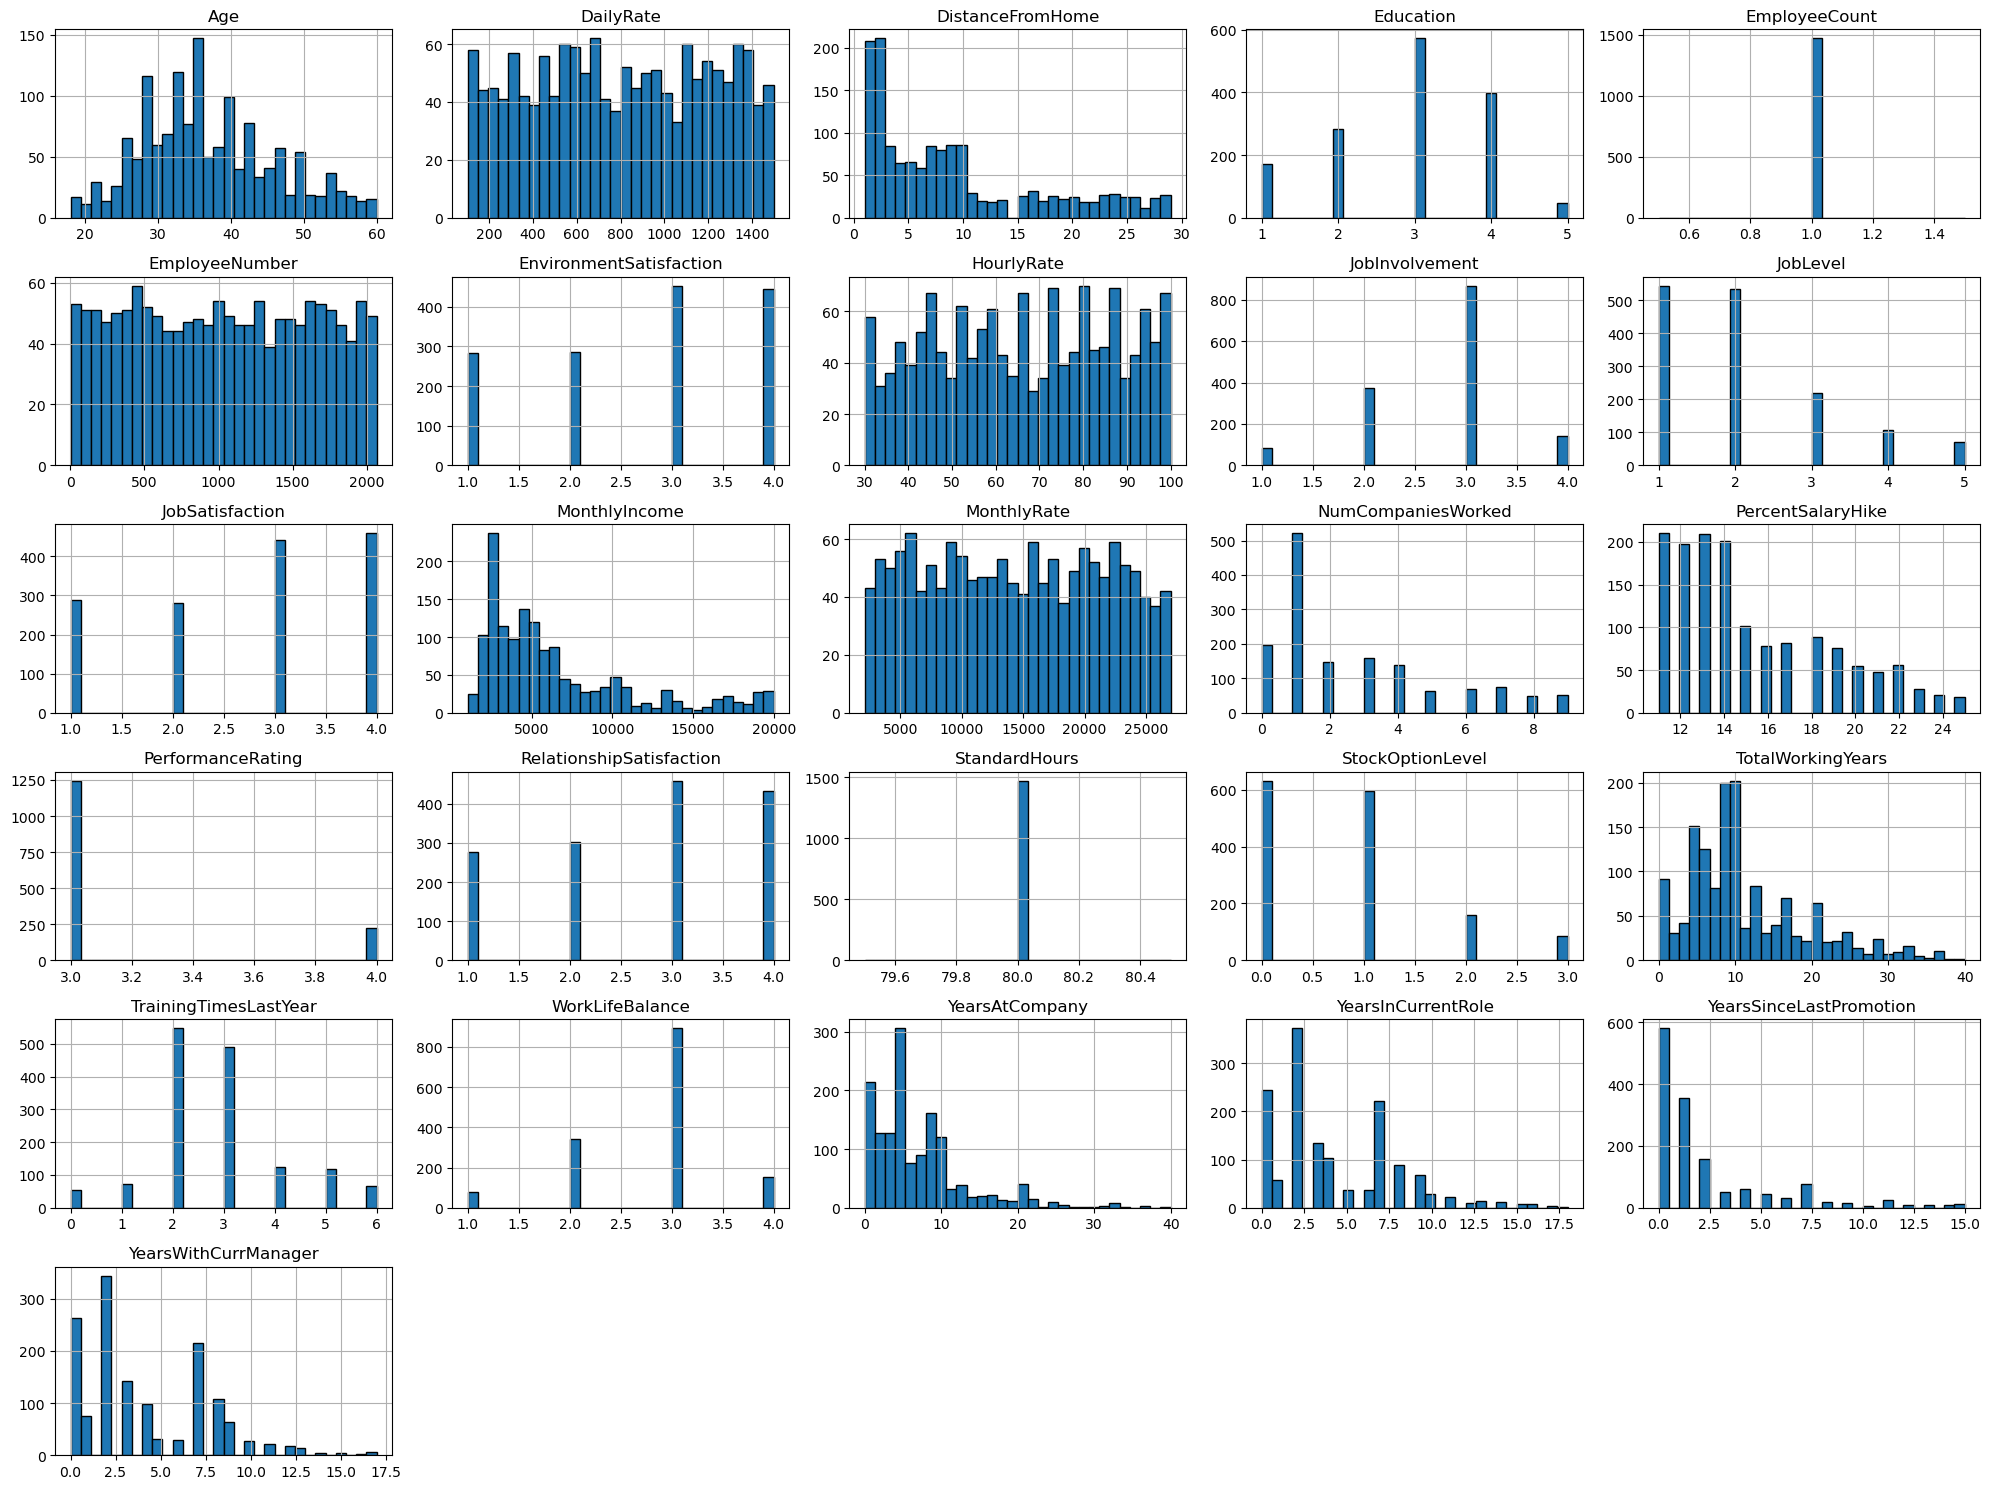

In [54]:
## # ID aur constant columns EDA me include nahi karenge
numeric_cols.drop(["EmployeeNumber",
    "EmployeeCount",
    "StandardHours"
    ])
df[numeric_cols].hist(
    figsize=(20,15),
    bins=30,
    edgecolor = 'black'
)
plt.tight_layout()
plt.show()

## Step 3.2 : Numerical Feature Distribution

The numerical feature distributions were analyzed using histograms.

### Key Observations

- Age follows an approximately normal distribution.
- MonthlyIncome is highly right-skewed.
- DistanceFromHome shows positive skewness.
- TotalWorkingYears, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, and YearsWithCurrManager are right-skewed.
- DailyRate, HourlyRate, and MonthlyRate are relatively uniformly distributed.
- EmployeeCount and StandardHours are constant features and will be removed during the data cleaning phase.
- PerformanceRating and Education are ordinal numerical features with discrete values.

## ```Step 3.3 : Categorical Feature Distribution```

In [55]:
categorical_cols = df.select_dtypes(include='object').columns

In [56]:
print((categorical_cols).tolist())

['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [57]:
numeric_cols

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

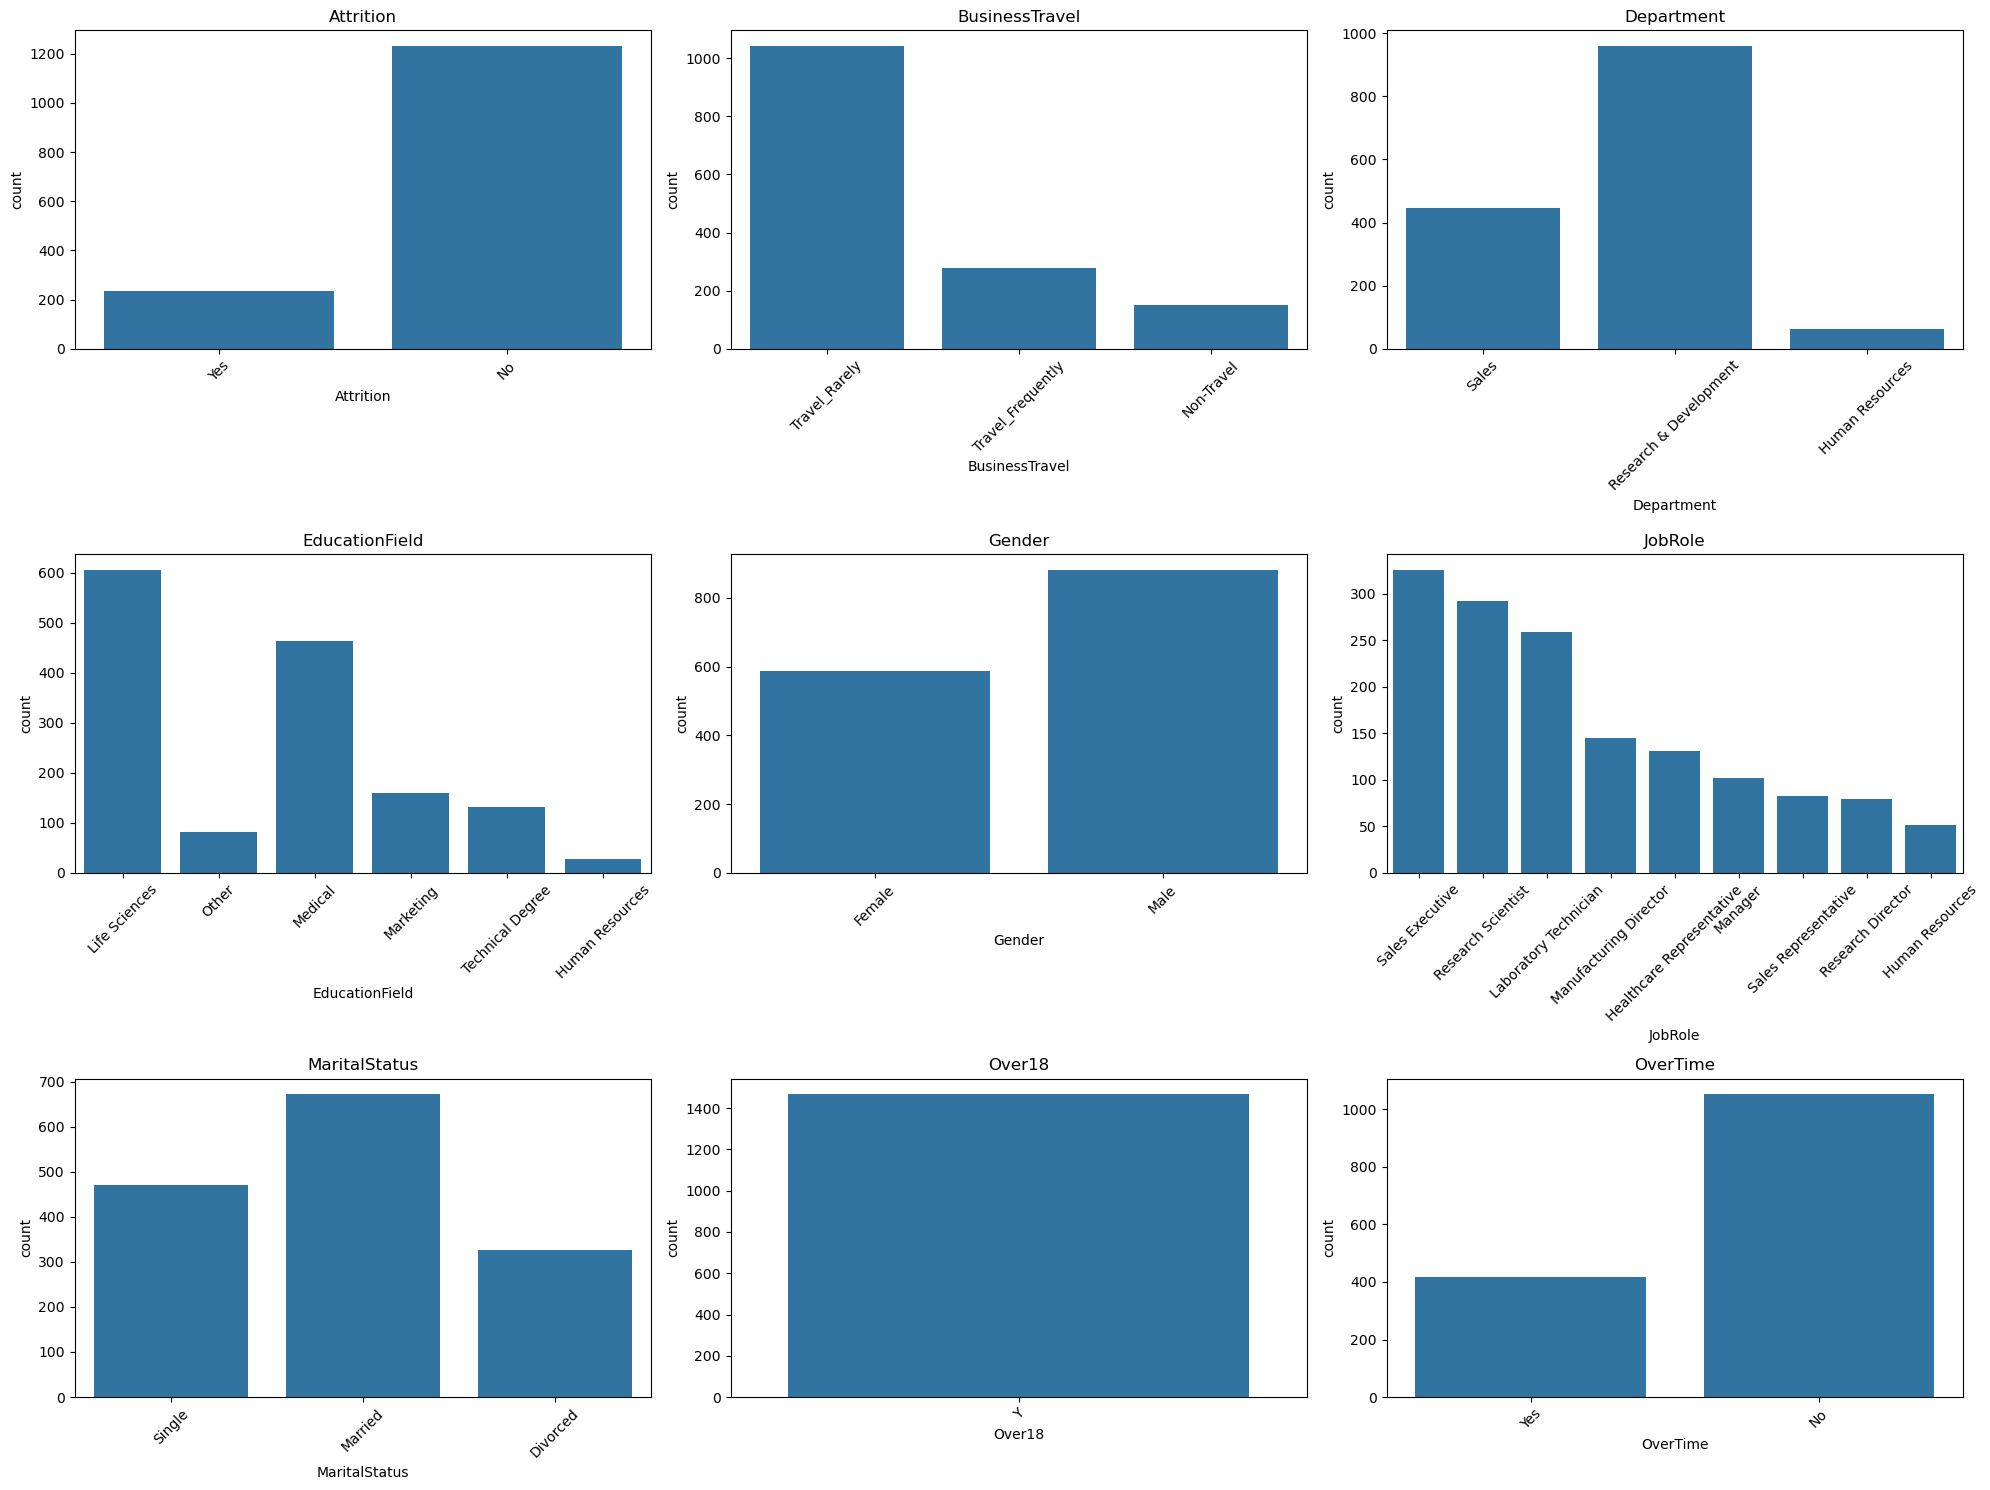

In [58]:

plt.figure(figsize=(20,15))
for i,col in enumerate(categorical_cols,1):
    plt.subplot(3,3,i)
    sns.countplot(data=df,x=col)
    plt.title(col)
    plt.xticks(rotation =45)
    plt.tight_layout()

## Step 3.3 : Categorical Feature Distribution

The categorical features were analyzed using count plots.

### Key Observations

- Most employees travel rarely.
- Research & Development is the largest department.
- Life Sciences is the most common education field.
- Male employees are slightly more than female employees.
- Sales Executive and Research Scientist are the most common job roles.
- Married employees form the largest marital status group.
- Most employees do not work overtime.
- The Over18 feature contains only one unique value ("Y") and will be removed during the data cleaning phase because it has zero variance.

## ``Step 3.4 : Numerical Features vs Attrition``

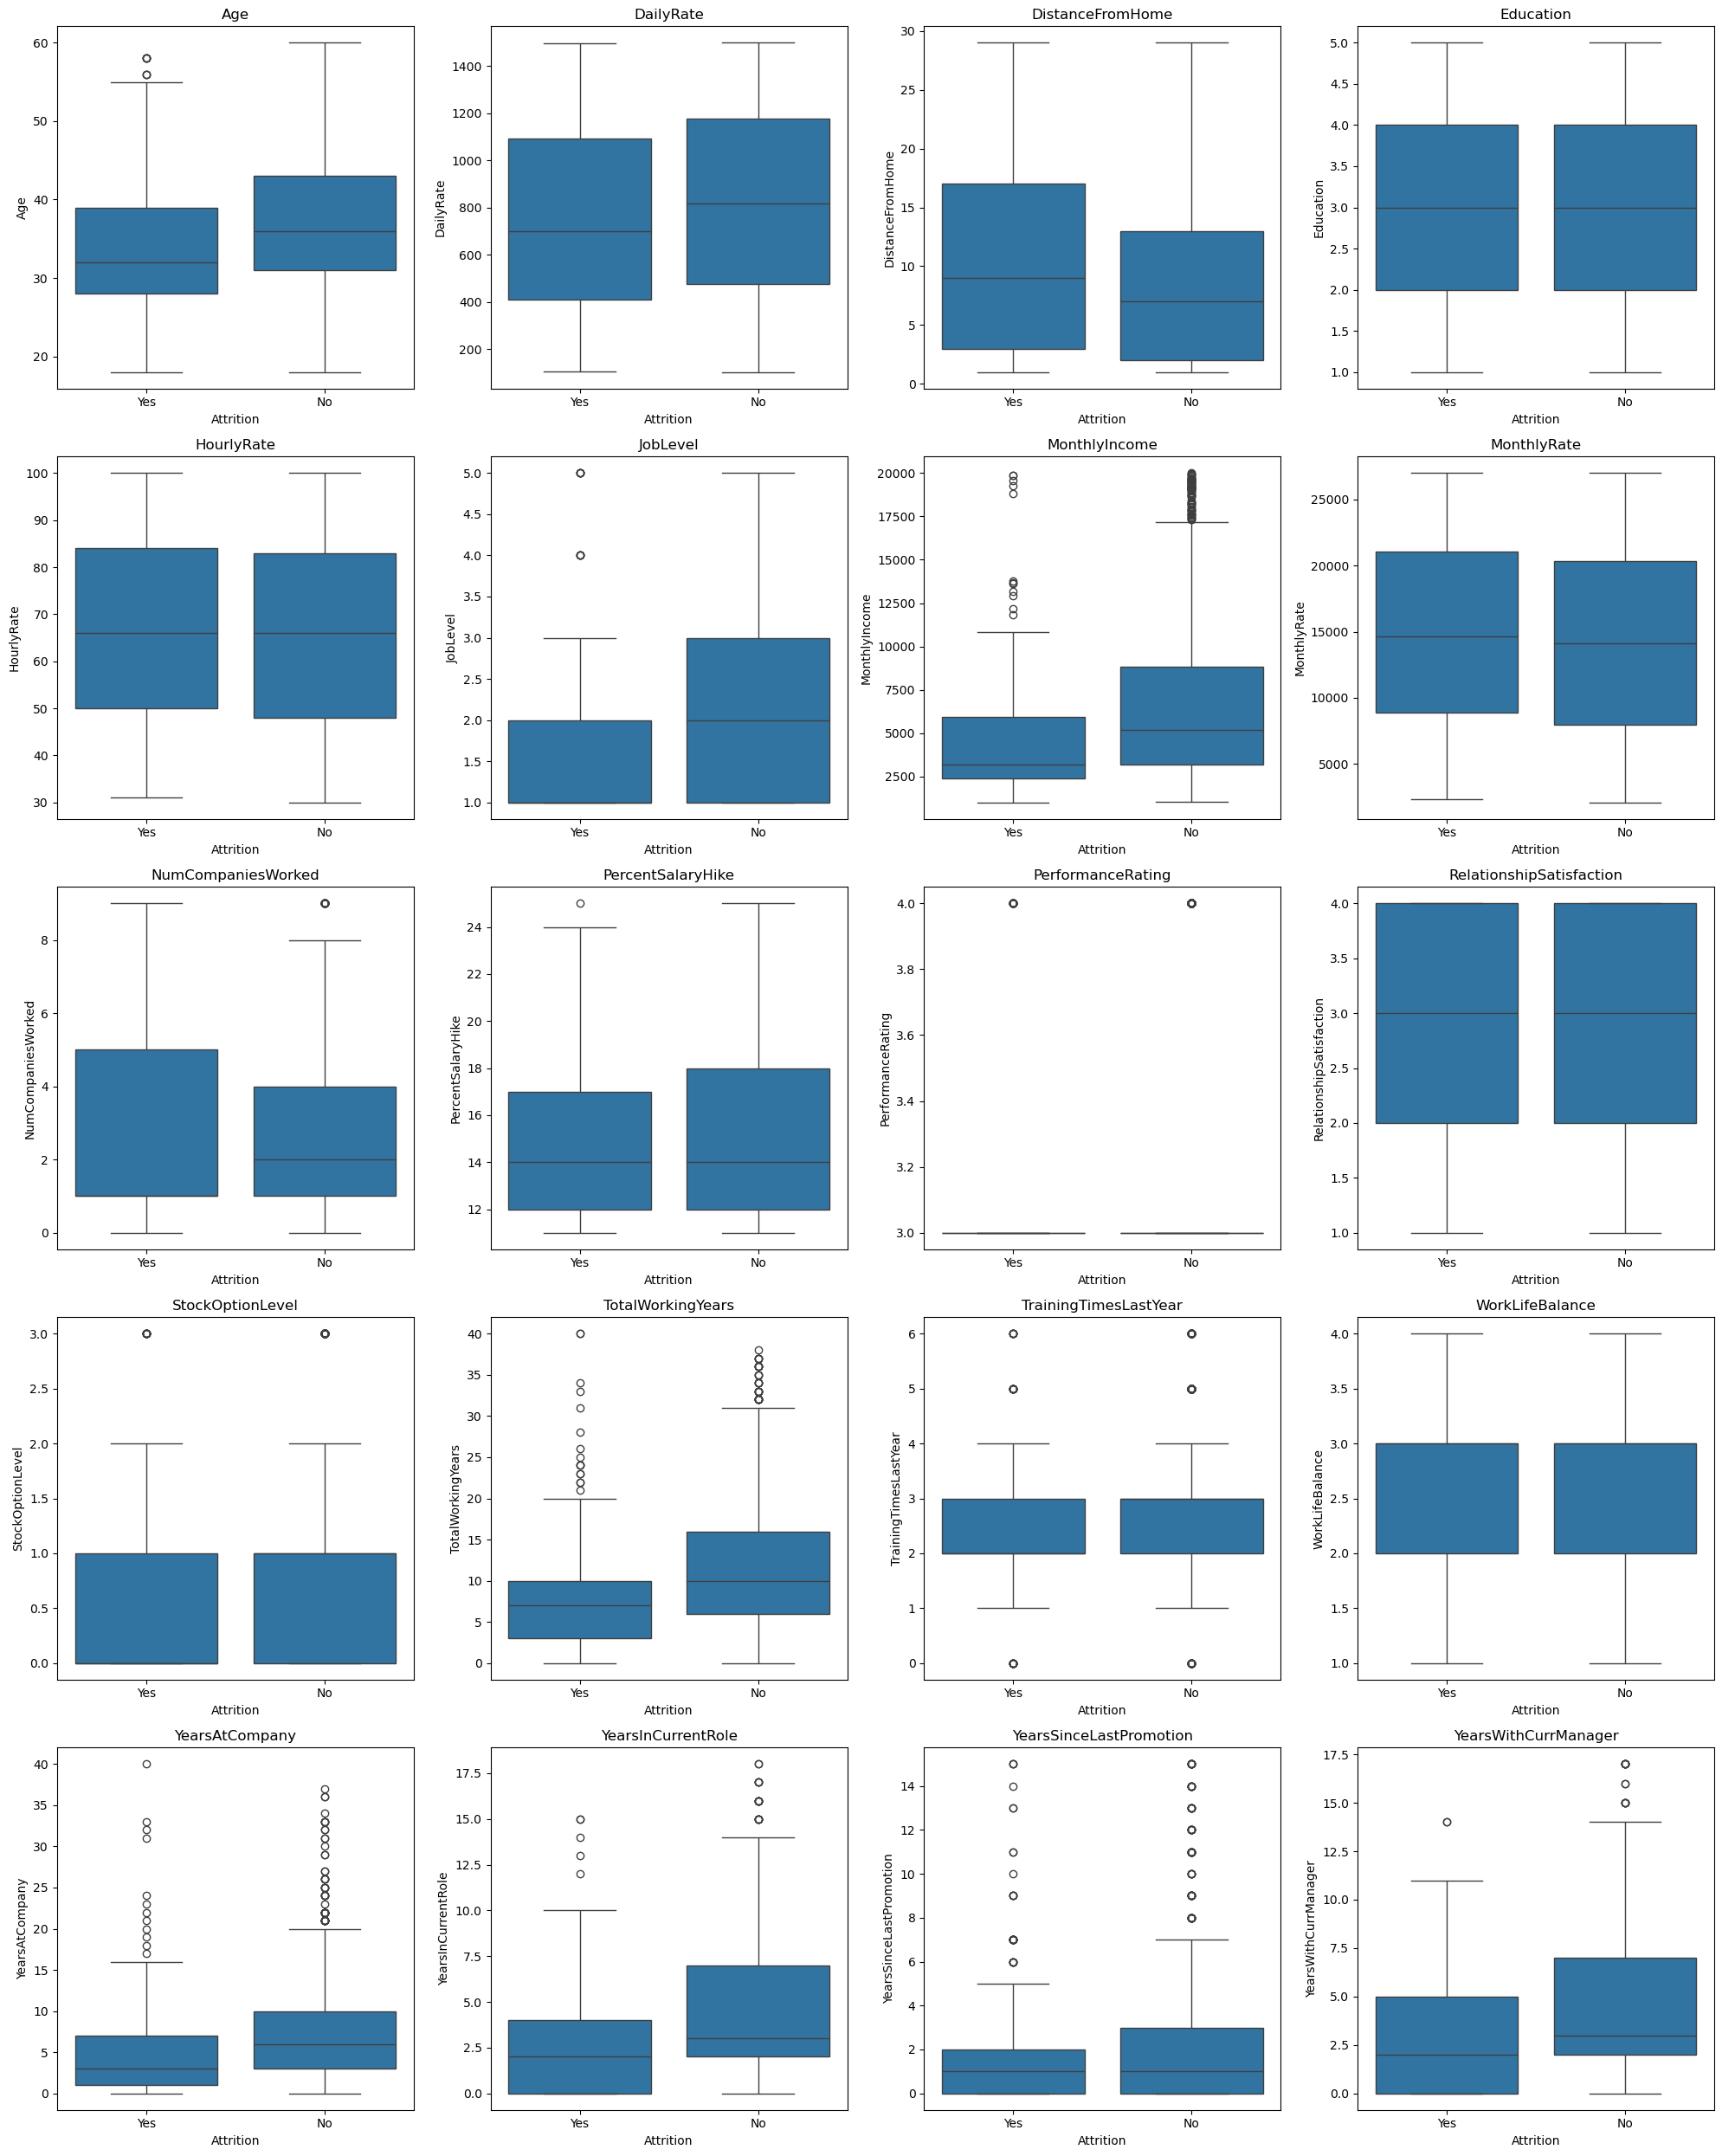

In [59]:
## remove tune nuemcal cols me ye ye missing_cols = [
#     'EmployeeCount',
#     'EmployeeNumber',
#     'EnvironmentSatisfaction',
#     'JobInvolvement',
#     'JobSatisfaction',
#     'StandardHours'
# ] 
 
numerical_cols = [
    'Age',
    'DailyRate',
    'DistanceFromHome',
    'Education',
    'HourlyRate',
    'JobLevel',
    'MonthlyIncome',
    'MonthlyRate',
    'NumCompaniesWorked',
    'PercentSalaryHike',
    'PerformanceRating',
    'RelationshipSatisfaction',
    'StockOptionLevel',
    'TotalWorkingYears',
    'TrainingTimesLastYear',
    'WorkLifeBalance',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]

plt.figure(figsize=(20,25))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(5,4,i)
    sns.boxplot(
        data=df,
        x="Attrition",
        y=col
    )
    plt.title(col)

plt.tight_layout()
plt.show()

## Step 3.4 : Numerical Features vs Attrition

Boxplots were used to compare numerical features across Attrition classes.

### Key Observations

- Younger employees show higher attrition.
- Employees with lower Job Levels have higher attrition.
- Employees with lower Monthly Income are more likely to leave.
- Employees with fewer Total Working Years tend to leave more frequently.
- Employees with fewer Years At Company have higher attrition.
- Employees with fewer Years In Current Role and Years With Current Manager also show relatively higher attrition.
- DailyRate, HourlyRate, MonthlyRate, PercentSalaryHike, PerformanceRating, RelationshipSatisfaction, StockOptionLevel, TrainingTimesLastYear, and WorkLifeBalance show relatively little visual separation between the two classes.

## `3.5 : Categorical Features vs Attrition`

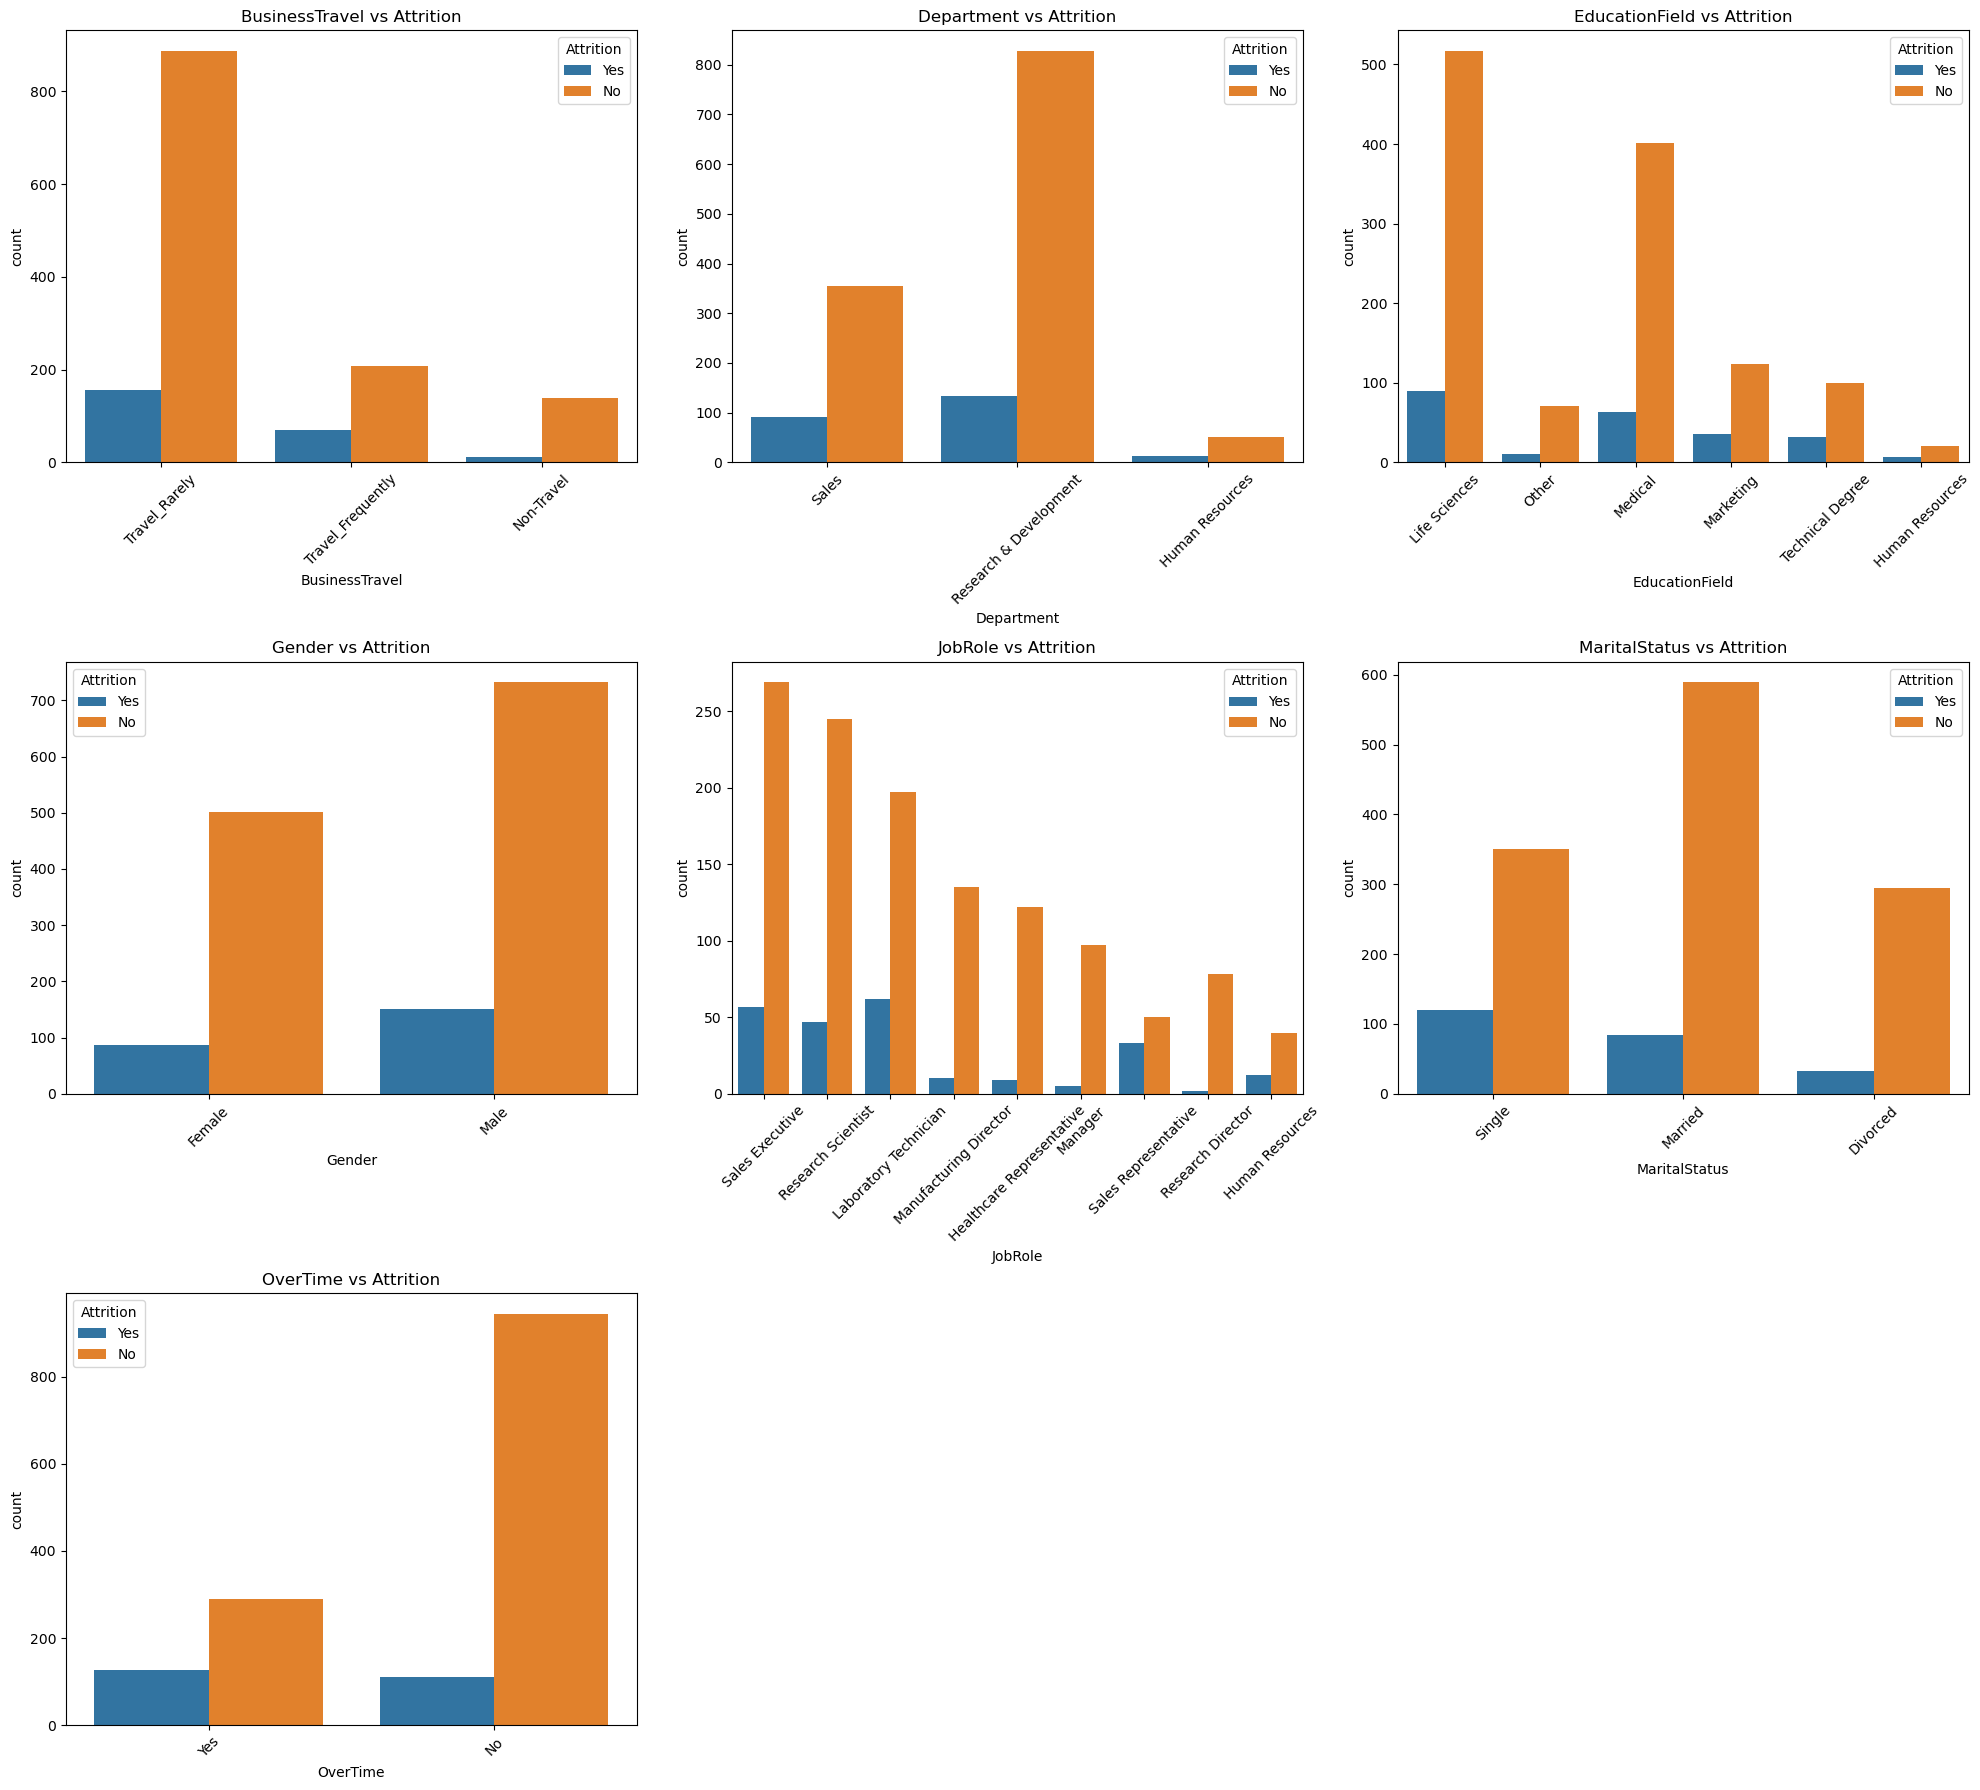

In [60]:
categorical_cols = [
    'BusinessTravel',
    'Department',
    'EducationField',
    'Gender',
    'JobRole',
    'MaritalStatus',
    'OverTime'
]

plt.figure(figsize=(20,18))

for i, col in enumerate(categorical_cols, 1):

    plt.subplot(3,3,i)

    sns.countplot(
        data=df,
        x=col,
        hue="Attrition"
    )

    plt.title(f"{col} vs Attrition")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Step 3.5 : Categorical Features vs Attrition

Categorical variables were compared with Attrition using count plots.

### Key Observations

- Employees who travel frequently tend to show higher attrition.
- Research & Development and Sales departments contain most attrition cases because they have the largest workforce.
- Life Sciences and Medical are the most common education fields among employees.
- Gender does not show a noticeable difference in attrition.
- Sales Executive, Laboratory Technician, and Research Scientist roles show relatively higher attrition.
- Single employees appear to have higher attrition than married employees.
- Employees working overtime show significantly higher attrition, making OverTime one of the strongest predictors.

## ```Step 3.6 : Correlation Heatmap```

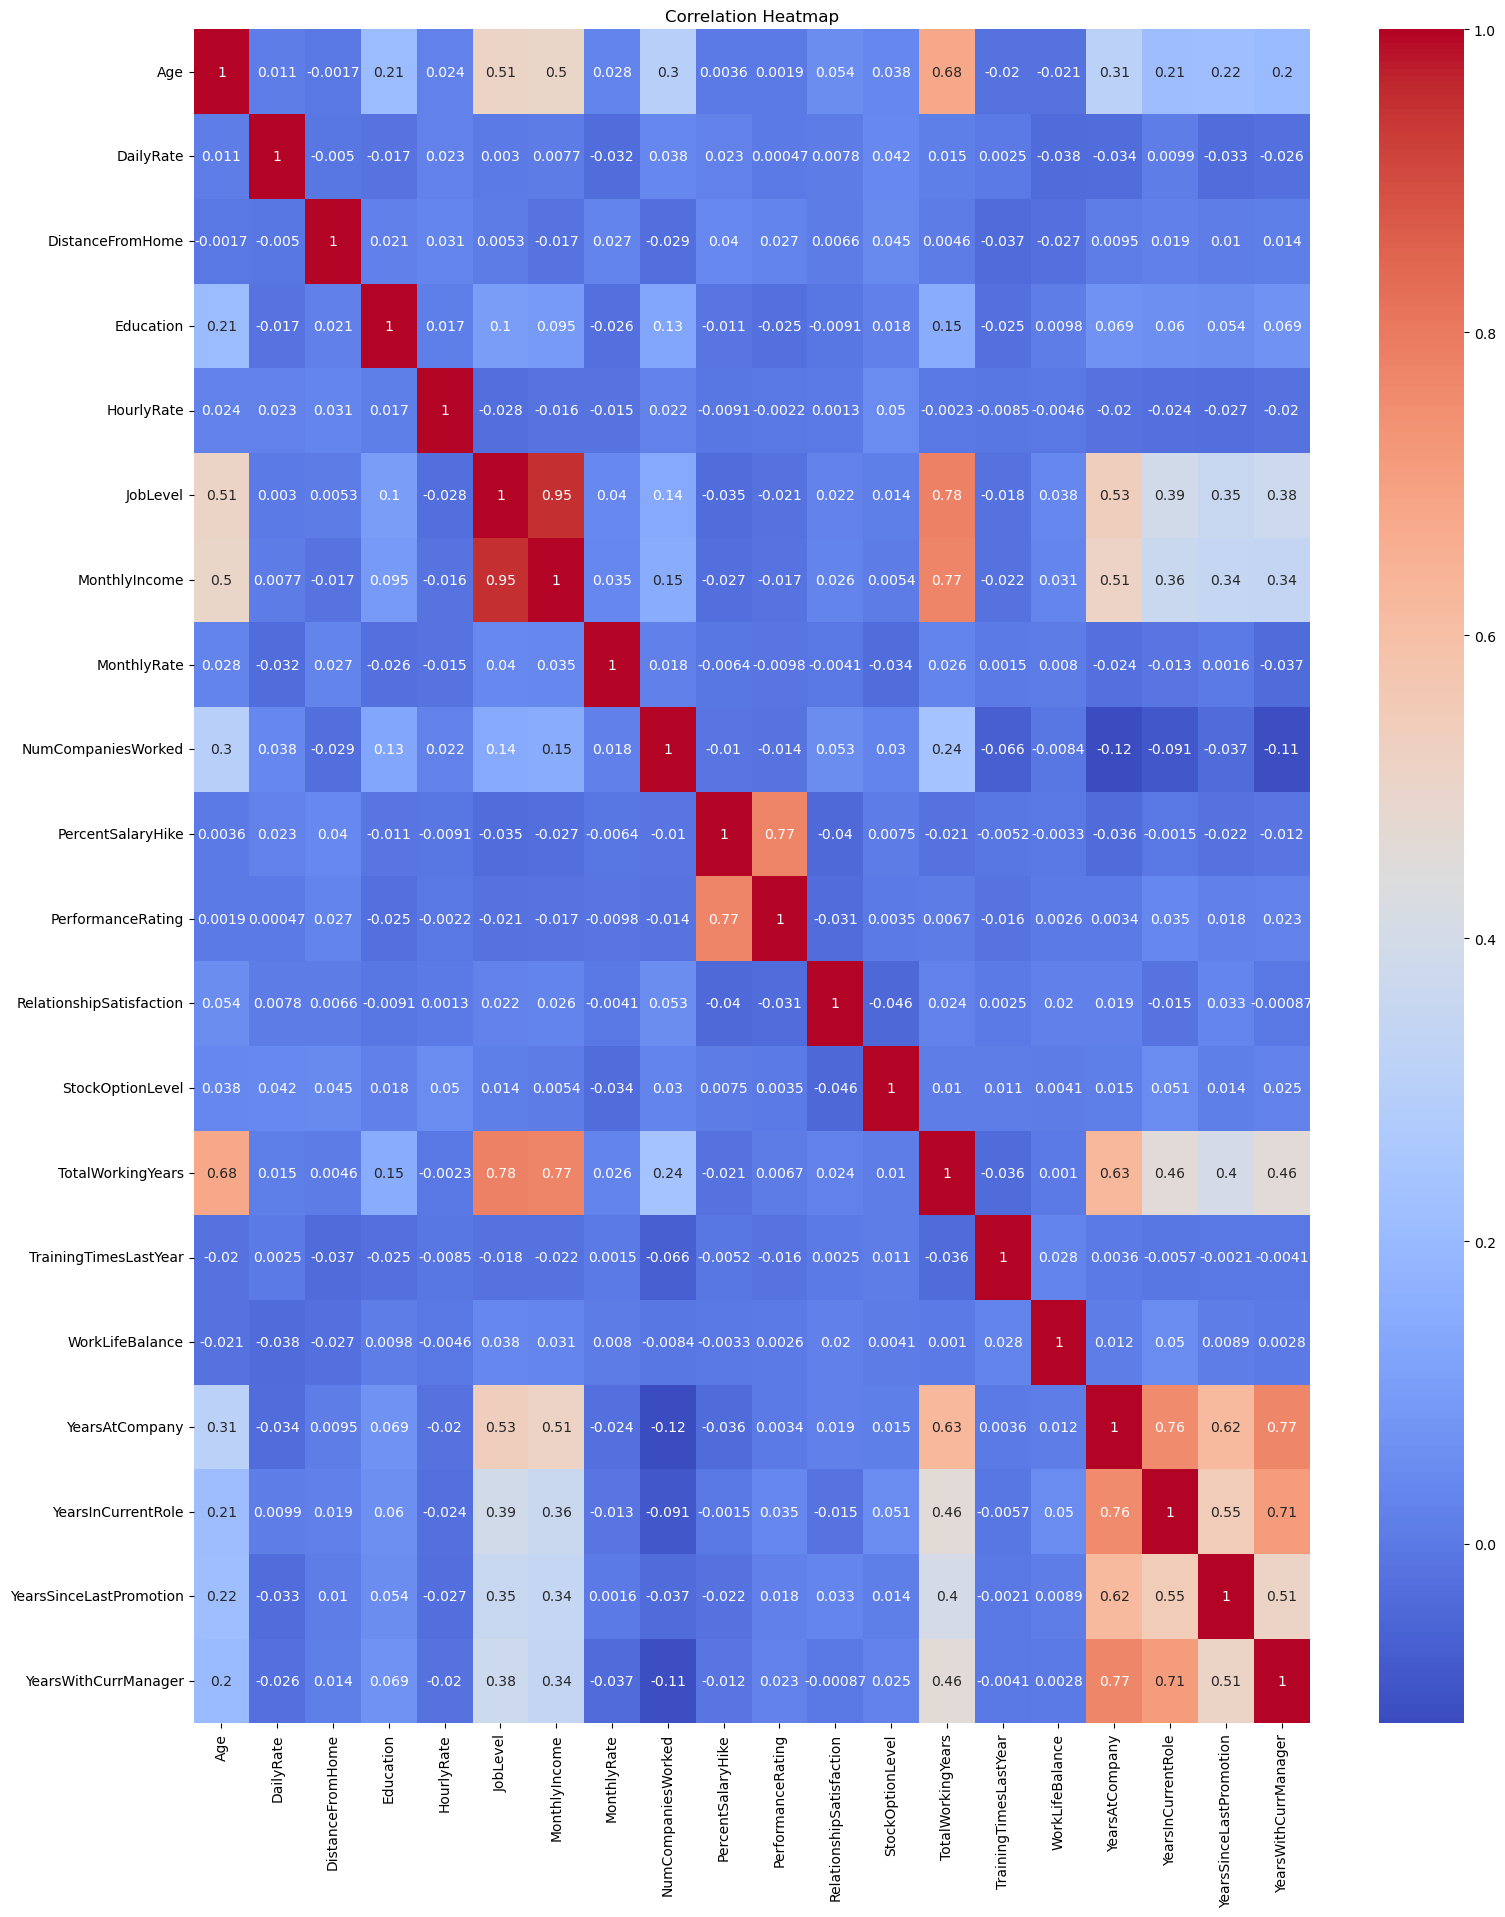

In [61]:
plt.figure(figsize=(18,22))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Step 3.6 : Correlation Heatmap

The correlation matrix was analyzed to identify relationships among numerical features.

### Key Observations

- JobLevel and MonthlyIncome show a very strong positive correlation (0.95).
- TotalWorkingYears is highly correlated with JobLevel (0.78) and MonthlyIncome (0.77).
- YearsAtCompany is strongly correlated with YearsWithCurrManager (0.77) and YearsInCurrentRole (0.76).
- PercentSalaryHike and PerformanceRating also show a strong positive correlation (0.77).
- Most other numerical features exhibit weak to moderate correlations, indicating limited multicollinearity.

## ``📌 Step 3.7 : Outlier Detection``

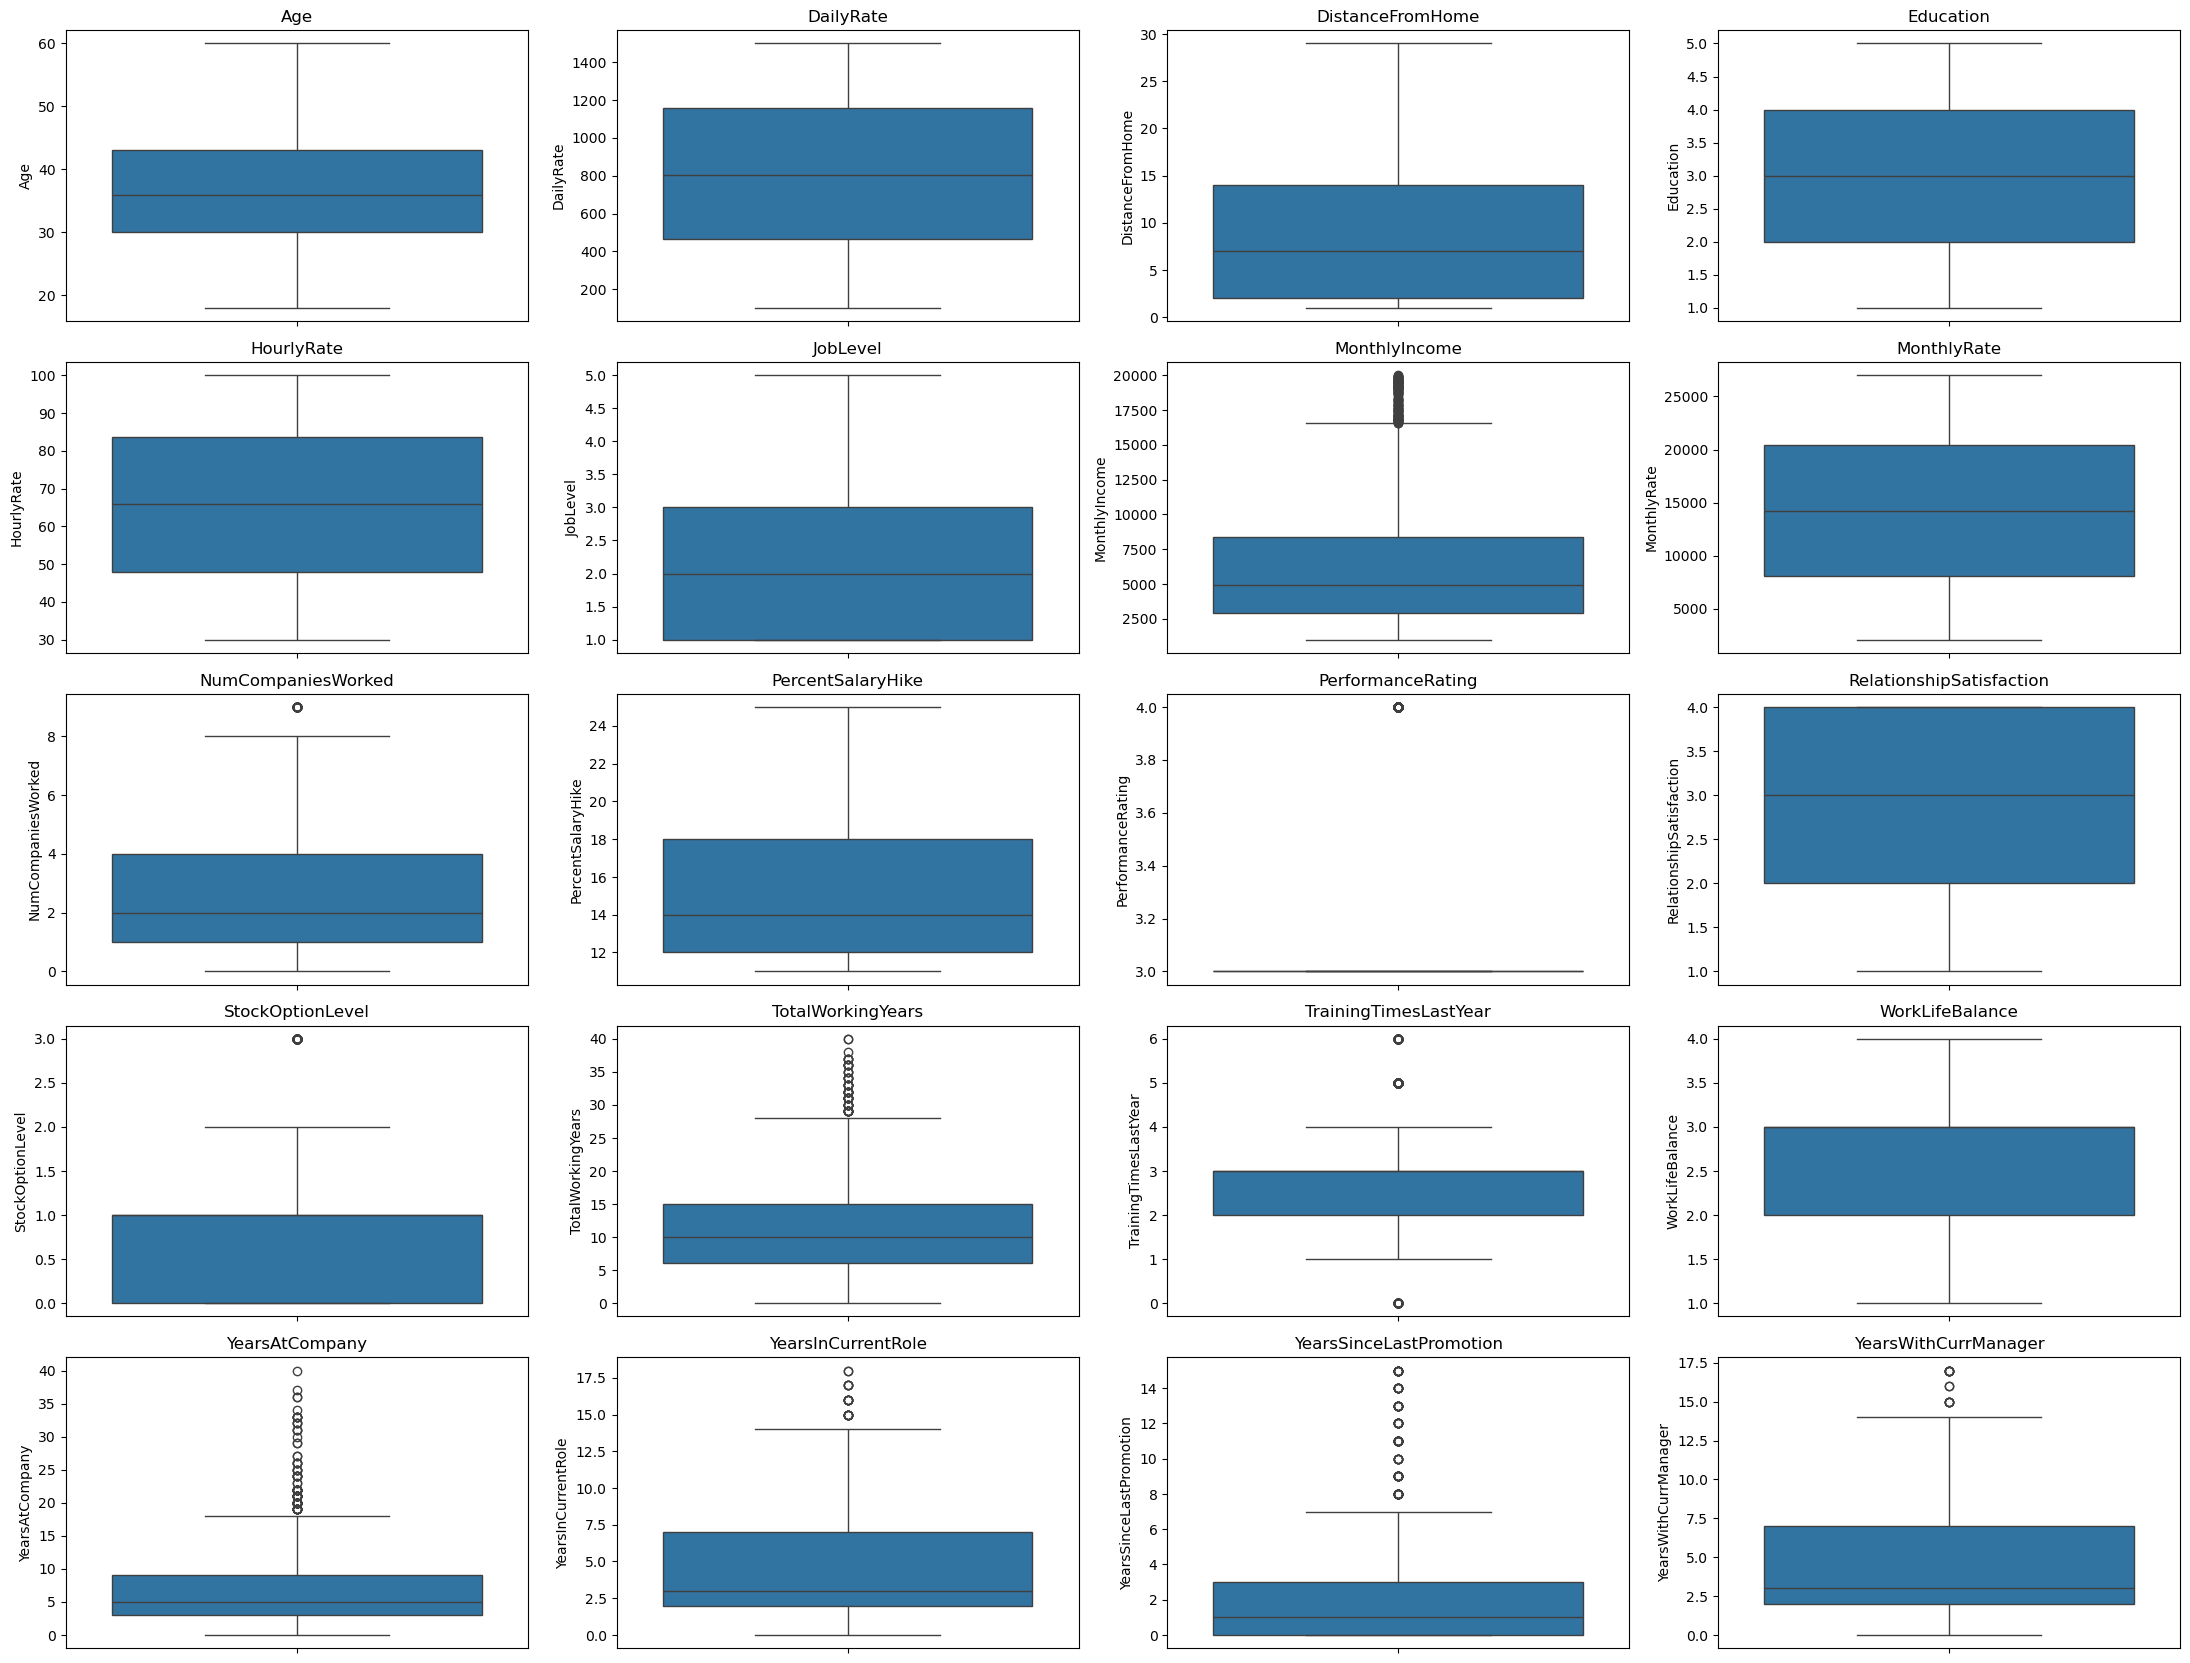

In [62]:
plt.figure(figsize=(22, 20))

for i, col in enumerate(numerical_cols, 1):

    plt.subplot(6, 4, i)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()
plt.show()

## Step 3.7 : Outlier Detection

Boxplots were used to detect potential outliers in numerical features.

### Key Observations

- MonthlyIncome contains high-value outliers.
- TotalWorkingYears contains employees with very high experience.
- YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, and YearsWithCurrManager also contain outliers.
- NumCompaniesWorked has a few extreme values.
- PerformanceRating and TrainingTimesLastYear show apparent outliers due to their discrete values.

Most detected outliers represent valid employee records rather than data entry errors.

Since tree-based algorithms are robust to outliers, no outlier treatment will be applied in this project.

## `` Step 3.8 : Final EDA Summary``

## Final EDA Summary

### Key Findings

- The dataset contains no missing values.
- No duplicate records were found.
- The target variable (Attrition) is imbalanced.
- EmployeeCount, StandardHours, and Over18 are constant features.
- EmployeeNumber is an identifier column.
- Younger employees tend to leave the company more frequently.
- Employees with lower MonthlyIncome, JobLevel, TotalWorkingYears, and YearsAtCompany show higher attrition.
- Employees working overtime are more likely to leave.
- JobRole and BusinessTravel also show noticeable differences across attrition classes.
- Several numerical features contain business-related outliers that will be retained.
- Some numerical features are strongly correlated (e.g., JobLevel and MonthlyIncome), but no feature will be removed based solely on correlation because tree-based models can handle multicollinearity effectively.

# ``Phase 4 : Data Cleaning``

### 📌 Step 4.1 — Remove Unnecessary / Constant Features

In [63]:
columns_to_drop = [
    "EmployeeCount",
    "StandardHours",
    "Over18",
    "EmployeeNumber"
]

df.drop(columns=columns_to_drop, inplace=True)

In [64]:
print(df.shape)
print(df.columns)

(1470, 31)
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')


EmployeeCount, StandardHours and Over18 were removed because they contain constant values and provide no useful information for prediction.

EmployeeNumber was removed because it is an identifier column and does not represent meaningful employee characteristics.

### 📌 Step 4.2 — Verify Missing Values

In [65]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

### Step 4.3 — Duplicate Rows Check

In [66]:
df.duplicated().sum()

np.int64(0)

### Step 4.4 — Outlier Detection

In [67]:
numerical_cols = df.select_dtypes(include='number').columns.tolist()

print(numeric_cols)

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')


In [68]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f"{col}: {len(outliers)} outliers")

Age: 0 outliers
DailyRate: 0 outliers
DistanceFromHome: 0 outliers
Education: 0 outliers
EnvironmentSatisfaction: 0 outliers
HourlyRate: 0 outliers
JobInvolvement: 0 outliers
JobLevel: 0 outliers
JobSatisfaction: 0 outliers
MonthlyIncome: 114 outliers
MonthlyRate: 0 outliers
NumCompaniesWorked: 52 outliers
PercentSalaryHike: 0 outliers
PerformanceRating: 226 outliers
RelationshipSatisfaction: 0 outliers
StockOptionLevel: 85 outliers
TotalWorkingYears: 63 outliers
TrainingTimesLastYear: 238 outliers
WorkLifeBalance: 0 outliers
YearsAtCompany: 104 outliers
YearsInCurrentRole: 21 outliers
YearsSinceLastPromotion: 107 outliers
YearsWithCurrManager: 14 outliers


Outliers were detected using the IQR method in several numerical features.
However, these observations were considered potentially valid employee records rather than data-entry errors. Therefore, no rows were removed based solely on IQR outlier detection.

##  Step 4.5 — Categorical Value Consistency Check

In [69]:
categorical_cols  = df.select_dtypes(include='object').columns.tolist()
print(categorical_cols)

['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [70]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


Attrition
['Yes' 'No']

BusinessTravel
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

Department
['Sales' 'Research & Development' 'Human Resources']

EducationField
['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']

Gender
['Female' 'Male']

JobRole
['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']

MaritalStatus
['Single' 'Married' 'Divorced']

OverTime
['Yes' 'No']


In [71]:
for col in categorical_cols:
    print(f"\n{'='*40}")
    print(col)
    print(df[col].value_counts())


Attrition
Attrition
No     1233
Yes     237
Name: count, dtype: int64

BusinessTravel
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

Department
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

EducationField
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

Gender
Gender
Male      882
Female    588
Name: count, dtype: int64

JobRole
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

MaritalStatus
MaritalStatus
Married     673


All categorical features were checked for inconsistent, unexpected,
or improperly formatted category values.

No extra spaces, spelling inconsistencies, or invalid categories
were identified. Therefore, no categorical value correction was required.

## Step 4.6 — Final Data Cleaning Verification

In [72]:
print("Shape :", df.shape)
print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Shape : (1470, 31)

Missing Values:
0

Duplicate Rows:
0

Data Types:
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StockOptionLevel             int64
TotalWorkingYears            int64
TrainingTimesLastYear        int64
WorkLifeBalance     

## 🚀 Phase 5 : Data Preprocessing

### ```Step 5.1 — Separate Features and Target```

In [73]:
X = df.drop('Attrition',axis=1)
y = df['Attrition']

In [74]:
print("X Shape :", X.shape)
print("y Shape :", y.shape)

print("\nTarget:")
print(y.value_counts())

X Shape : (1470, 30)
y Shape : (1470,)

Target:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


The target variable Attrition was separated from the feature variables.

X contains the employee-related features, while y contains the target variable indicating whether the employee left the organization.

### ```Step 5.2 — Train-Test Split```

In [75]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y
)
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (1176, 30)
X_test  : (294, 30)
y_train : (1176,)
y_test  : (294,)


In [76]:
print("\nTraining Target Distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting Target Distribution:")
print(y_test.value_counts(normalize=True) * 100)


Training Target Distribution:
Attrition
No     83.843537
Yes    16.156463
Name: proportion, dtype: float64

Testing Target Distribution:
Attrition
No     84.013605
Yes    15.986395
Name: proportion, dtype: float64


The dataset was split into training and testing sets using an 80:20 ratio with stratified sampling.

The target distribution remained nearly identical in both sets, with approximately 84% No and 16% Yes observations.

### ```Step 5.3 — Identify Numerical & Categorical Features```

In [77]:
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
numerical_cols = X_train.select_dtypes(exclude="object").columns.tolist()

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Numerical Columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


### ```Step 5.4 — Create ColumnTransformer```

In [78]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
numerical_cols = X_train.select_dtypes(exclude="object").columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_cols
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_cols
        )
    ]
)

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Numerical Columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


###  ```Step 5.5 — Encode Target Variable```

In [79]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print("Classes:", le.classes_)

Classes: ['No' 'Yes']


## Phase 6 : Baseline Models

### ``Step 6.1 — Create Model Pipeline``

A machine learning pipeline was created to combine data preprocessing and model training into a single workflow.

The pipeline applies StandardScaler to numerical features and OneHotEncoder to categorical features before training the model.

In [80]:
from sklearn.pipeline import Pipeline

def create_pipeline(model):
    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

In [81]:
from sklearn.linear_model import LogisticRegression

logistic_pipeline = create_pipeline(
    LogisticRegression(max_iter=1000)
)

logistic_pipeline.fit(X_train, y_train)

y_pred = logistic_pipeline.predict(X_test)

In [82]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label="Yes"))
print("Recall   :", recall_score(y_test, y_pred, pos_label="Yes"))
print("F1 Score :", f1_score(y_test, y_pred, pos_label="Yes"))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.8639455782312925
Precision: 0.64
Recall   : 0.3404255319148936
F1 Score : 0.4444444444444444

Confusion Matrix
[[238   9]
 [ 31  16]]

Classification Report
              precision    recall  f1-score   support

          No       0.88      0.96      0.92       247
         Yes       0.64      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.76      0.65      0.68       294
weighted avg       0.85      0.86      0.85       294



Logistic Regression achieved 86.39% accuracy. However, its recall for the Attrition = Yes class was only 34.04%, indicating that the model missed a significant number of employees likely to leave.

In [83]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score

models = {
    'Logistic Regression': LogisticRegression(),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Extra Trees': ExtraTreesClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'GaussianNB': GaussianNB(),
    'LDA': LinearDiscriminantAnalysis()
}

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred, pos_label="Yes"
        ),
        "Recall": recall_score(
            y_test, y_pred, pos_label="Yes"
        ),
        "F1 Score": f1_score(
            y_test, y_pred, pos_label="Yes"
        )
    })

In [84]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
9,LDA,0.863946,0.620690,0.382979,0.473684
0,Logistic Regression,0.863946,0.640000,0.340426,0.444444
8,GaussianNB,0.615646,0.250000,0.702128,0.368715
6,AdaBoost,0.843537,0.521739,0.255319,0.342857
3,Decision Tree,0.758503,0.293103,0.361702,0.323810
7,Gradient Boosting,0.850340,0.588235,0.212766,0.312500
5,Extra Trees,0.850340,0.615385,0.170213,0.266667
2,SVM,0.857143,0.777778,0.148936,0.250000
1,KNN,0.836735,0.454545,0.106383,0.172414
4,Random Forest,0.833333,0.416667,0.106383,0.169492


### Baseline Model Comparison

The baseline models showed that accuracy alone was not sufficient for evaluating the models because the Attrition target is imbalanced.

LDA achieved the highest F1-score for the Attrition = Yes class at 47.37%, while Logistic Regression achieved an F1-score of 44.44%.

Gaussian Naive Bayes achieved the highest recall of 70.21%, but its precision was only 25%, indicating a high number of false positives.

Overall, the baseline results indicate that class imbalance is affecting the model's ability to correctly identify employees likely to leave.

### ```Step 6.5 — Handle Class Imbalance using SMOTE```

The baseline evaluation showed that the imbalanced target variable
affected the model's ability to identify Attrition = Yes.

SMOTE is used to generate synthetic samples for the minority class.
It will be applied only to the training data, while the test data
will remain unchanged for unbiased evaluation.

In [85]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
smote_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000))
])

smote_pipeline.fit(X_train, y_train)

y_pred = smote_pipeline.predict(X_test)

### ````Step 6.6 — SMOTE Model Evaluation````

In [86]:
smote_results = []

for name, model in models.items():

    pipeline = ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test, y_pred, pos_label="Yes"
    )
    recall = recall_score(
        y_test, y_pred, pos_label="Yes"
    )
    f1 = f1_score(
        y_test, y_pred, pos_label="Yes"
    )

    smote_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    print("=" * 60)
    print(name)
    print("=" * 60)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

Logistic Regression
Accuracy : 0.7721
Precision: 0.3780
Recall   : 0.6596
F1 Score : 0.4806
KNN
Accuracy : 0.5680
Precision: 0.2101
Recall   : 0.6170
F1 Score : 0.3135
SVM
Accuracy : 0.8367
Precision: 0.4878
Recall   : 0.4255
F1 Score : 0.4545
Decision Tree
Accuracy : 0.7687
Precision: 0.2857
Recall   : 0.2979
F1 Score : 0.2917
Random Forest
Accuracy : 0.8537
Precision: 0.6250
Recall   : 0.2128
F1 Score : 0.3175
Extra Trees
Accuracy : 0.8537
Precision: 0.6250
Recall   : 0.2128
F1 Score : 0.3175
AdaBoost
Accuracy : 0.8401
Precision: 0.5000
Recall   : 0.4681
F1 Score : 0.4835
Gradient Boosting
Accuracy : 0.8605
Precision: 0.6250
Recall   : 0.3191
F1 Score : 0.4225
GaussianNB
Accuracy : 0.5170
Precision: 0.2013
Recall   : 0.6809
F1 Score : 0.3107
LDA
Accuracy : 0.7517
Precision: 0.3415
Recall   : 0.5957
F1 Score : 0.4341


In [87]:
smote_results_df = pd.DataFrame(smote_results)

smote_results_df = smote_results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

smote_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,AdaBoost,0.8401,0.5000,0.4681,0.4835
1,Logistic Regression,0.7721,0.3780,0.6596,0.4806
2,SVM,0.8367,0.4878,0.4255,0.4545
3,LDA,0.7517,0.3415,0.5957,0.4341
4,Gradient Boosting,0.8605,0.6250,0.3191,0.4225
5,Random Forest,0.8537,0.6250,0.2128,0.3175
6,Extra Trees,0.8537,0.6250,0.2128,0.3175
7,KNN,0.5680,0.2101,0.6170,0.3135
8,GaussianNB,0.5170,0.2013,0.6809,0.3107
9,Decision Tree,0.7687,0.2857,0.2979,0.2917


SMOTE significantly improved the recall of the minority class (Attrition = Yes) for several models. Logistic Regression showed the largest recall improvement, increasing from 34.04% to 65.96%.

AdaBoost achieved the highest F1-score after SMOTE at 48.35%. Therefore, SMOTE improved the model's ability to identify potential employee attrition, although some models experienced a decrease in accuracy or F1-score.

## Phase 7 — Cross Validation

In [88]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
top_models = {
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC()
}
cv_results = []

from sklearn.metrics import make_scorer

scoring = {
    "accuracy": "accuracy",

    "precision": make_scorer(
        precision_score,
        pos_label="Yes"
    ),

    "recall": make_scorer(
        recall_score,
        pos_label="Yes"
    ),

    "f1": make_scorer(
        f1_score,
        pos_label="Yes"
    )
}

for name, model in top_models.items():

    pipeline = ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Precision Mean": scores["test_precision"].mean(),
        "Recall Mean": scores["test_recall"].mean(),
        "F1 Mean": scores["test_f1"].mean(),
        "F1 Std": scores["test_f1"].std()
    })

In [89]:
cv_results_df = pd.DataFrame(cv_results)

cv_results_df.sort_values(
    by="F1 Mean",
    ascending=False
).round(4)

,Model,Accuracy Mean,Precision Mean,Recall Mean,F1 Mean,F1 Std
0,AdaBoost,0.8520,0.5437,0.5579,0.5475,0.0411
1,Logistic Regression,0.7797,0.4023,0.7105,0.5114,0.0354
2,SVM,0.8452,0.5315,0.4263,0.4688,0.0865


Cross-validation showed that AdaBoost achieved the highest mean F1-score
(54.75%) and maintained good stability with an F1 standard deviation of
4.11%. Logistic Regression achieved the highest recall (71.05%), making
it useful for identifying potential attrition cases. Therefore, AdaBoost
and Logistic Regression were selected for hyperparameter tuning.

### Phase 8 — Hyperparameter Tuning

In [90]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

In [91]:
from sklearn.metrics import make_scorer

f1_scorer = make_scorer(
    f1_score,
    pos_label="Yes"
)

In [92]:
ada_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", AdaBoostClassifier(random_state=42))
])

ada_params = {
    "model__n_estimators": randint(50, 300),
    "model__learning_rate": uniform(0.01, 1.0)
}

ada_search = RandomizedSearchCV(
    estimator=ada_pipeline,
    param_distributions=ada_params,
    n_iter=20,
    scoring=f1_scorer,       # 👈 changed
    cv=cv,
    random_state=42,
    n_jobs=-1
)

ada_search.fit(X_train, y_train)

print("Best AdaBoost Parameters:")
print(ada_search.best_params_)

print("\nBest CV F1:")
print(ada_search.best_score_)

Best AdaBoost Parameters:
{'model__learning_rate': np.float64(0.6218528947223795), 'model__n_estimators': 219}

Best CV F1:
0.5978266375043167


In [93]:
lr_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=2000))
])

lr_params = {
    "model__C": uniform(0.01, 10),
    "model__solver": ["liblinear", "lbfgs"],
    "model__class_weight": [None, "balanced"]
}

lr_search = RandomizedSearchCV(
    estimator=lr_pipeline,
    param_distributions=lr_params,
    n_iter=20,
    scoring=f1_scorer,       # 👈 changed
    cv=cv,
    random_state=42,
    n_jobs=-1
)

lr_search.fit(X_train, y_train)

print("Best Logistic Regression Parameters:")
print(lr_search.best_params_)

print("\nBest CV F1:")
print(lr_search.best_score_)

Best Logistic Regression Parameters:
{'model__C': np.float64(1.5701864044243652), 'model__class_weight': None, 'model__solver': 'liblinear'}

Best CV F1:
0.5140640768817196


In [94]:
print("AdaBoost Best F1 :", ada_search.best_score_)
print("Logistic Best F1 :", lr_search.best_score_)

AdaBoost Best F1 : 0.5978266375043167
Logistic Best F1 : 0.5140640768817196


After RandomizedSearchCV, AdaBoost achieved the highest cross-validated
F1-score of 59.78%, outperforming Logistic Regression with an F1-score
of 51.41%.

Therefore, AdaBoost was selected as the final candidate model for
evaluation on the unseen test set.

In [95]:
best_model = ada_search.best_estimator_

y_pred = best_model.predict(X_test)

print("=" * 60)
print("FINAL MODEL : AdaBoost")
print("=" * 60)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, pos_label='Yes'):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred, pos_label='Yes'):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred, pos_label='Yes'):.4f}")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

FINAL MODEL : AdaBoost
Accuracy : 0.8503
Precision: 0.5455
Recall   : 0.3830
F1 Score : 0.4500

Confusion Matrix
[[232  15]
 [ 29  18]]

Classification Report
              precision    recall  f1-score   support

          No       0.89      0.94      0.91       247
         Yes       0.55      0.38      0.45        47

    accuracy                           0.85       294
   macro avg       0.72      0.66      0.68       294
weighted avg       0.83      0.85      0.84       294



### Final Model Evaluation

The tuned AdaBoost model achieved an accuracy of 85.03% on the unseen test set.

For the Attrition = Yes class, the model achieved 54.55% precision,
38.30% recall, and an F1-score of 45.00%.

Although AdaBoost achieved a higher cross-validation F1-score after
hyperparameter tuning, its performance on the unseen test set was lower.
This indicates that the tuned model did not generalize as well as expected.